# FPO Violation, Stim Interactions


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype


from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_filtered_itrx_exp = "2025_04_17_fig4_fit_filtered_prev_viol_stim_intrx_n_rs47.pkl"

compare_exp = "2025_04_16_fig4_compare_intrxs_rs47.pkl"

binary_compare_exp ="2025_04_16_fig5_compare_to_binary_rs47.pkl"

# Post Violation Hit Rates


In [4]:
hit_rates_by_viol_hist = pd.read_csv(
   DATA_PATH + "/hit_rates_by_viol_hist_long.csv"
)
hit_rates_by_viol_hist.head()

,animal_id,prev_violation,hit,percent_correct
0,W051,0,0.802936,80.293573
1,W051,1,0.766545,76.654478
2,W060,0,0.830631,83.063119
3,W060,1,0.783092,78.309221
4,W065,0,0.776971,77.697107


Text(0.5, 1.0, '')

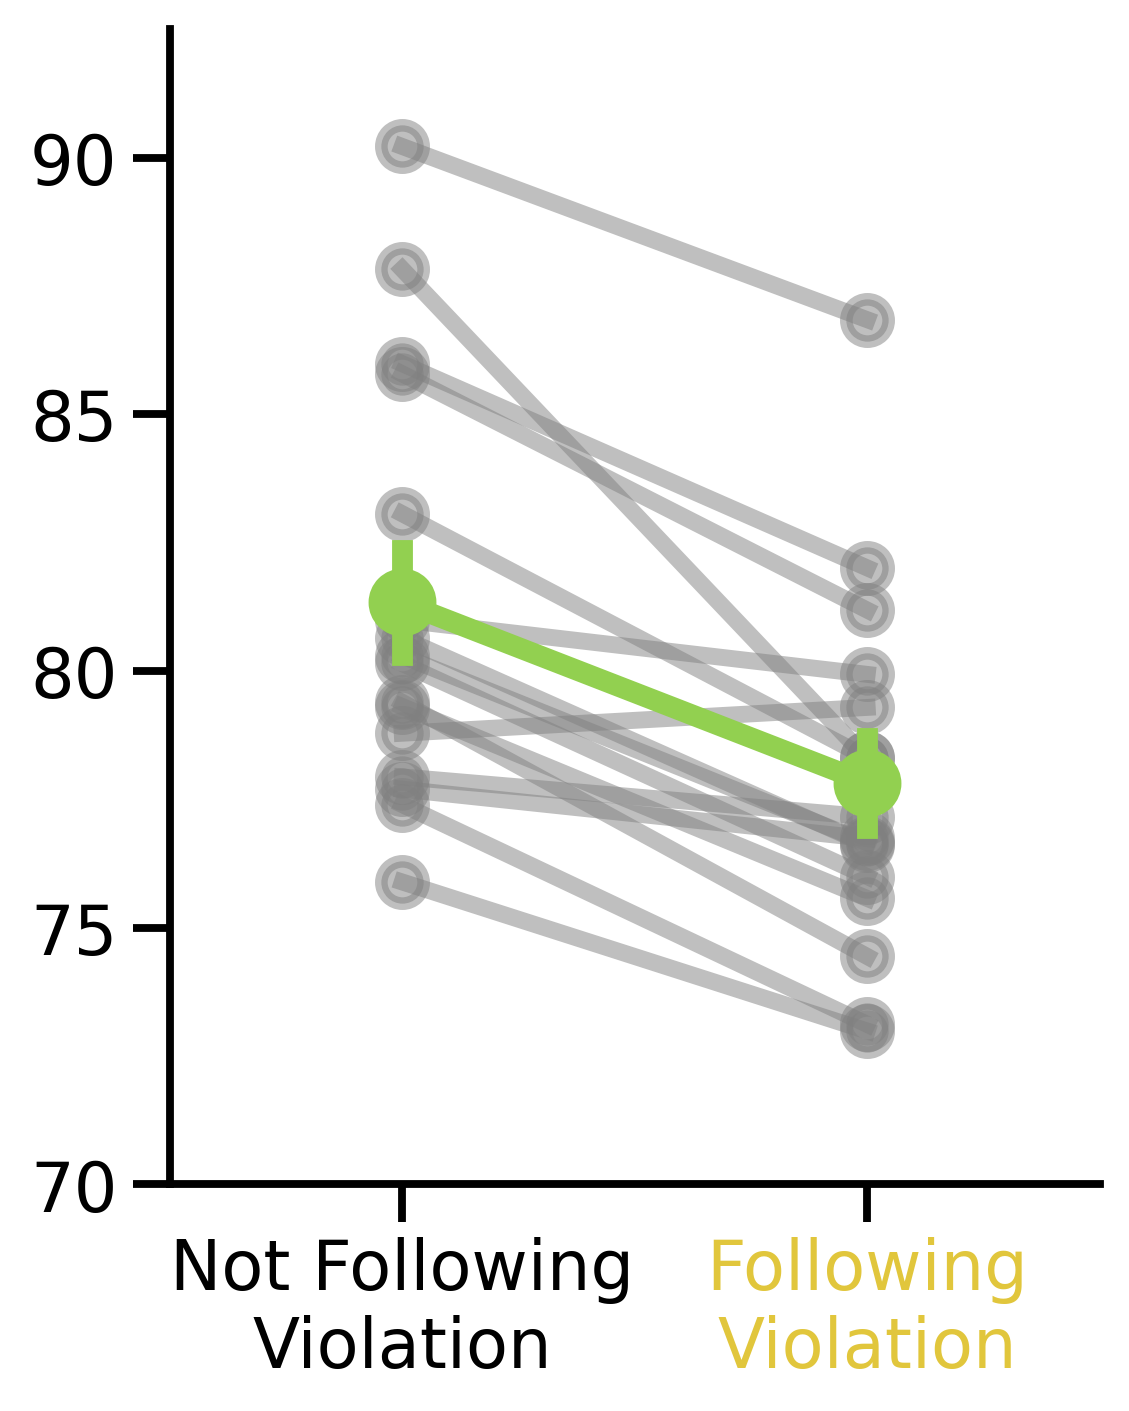

In [23]:
fig, ax = plt.subplots(figsize=(4, 5), dpi=300)

sns.despine()

sns.pointplot(data=hit_rates_by_viol_hist, x="prev_violation", y="percent_correct", hue="animal_id", ax=ax, palette=["gray"] * 16, alpha=0.5)

sns.pointplot(data=hit_rates_by_viol_hist, x="prev_violation", y="percent_correct", ax=ax, color="#92D050", errorbar="se", lw=5)

ax.get_legend().remove()

ax.set_xticks(range(2))
# Set the tick labels
ax.set_xticklabels(["Not Following\nViolation", "Following\nViolation"])

# Get the tick labels
tick_labels = ax.get_xticklabels()

# Set the colors for each label
colors = ["k", c.VIOLATION_COLOR]
for label, color in zip(tick_labels, colors):
    label.set_color(color)

ax.set(ylim=(70, 92.5), ylabel=(""), xlabel="")
ax.set_yticks(range(70, 93, 5))  # Set y ticks every 5
ax.set_title("")

> Note stats test in @fig4 NB


## Interaction Term Design


In [2]:
demo_data = pd.read_csv("data/demo_intuition_data.csv")
ylim=(-0.1, 1.1)

In [3]:
demo_data.head()
demo_data["s_a_x_filt_prev_violation"] = demo_data["s_a"] * demo_data["prev_violation_exp_tau1"]

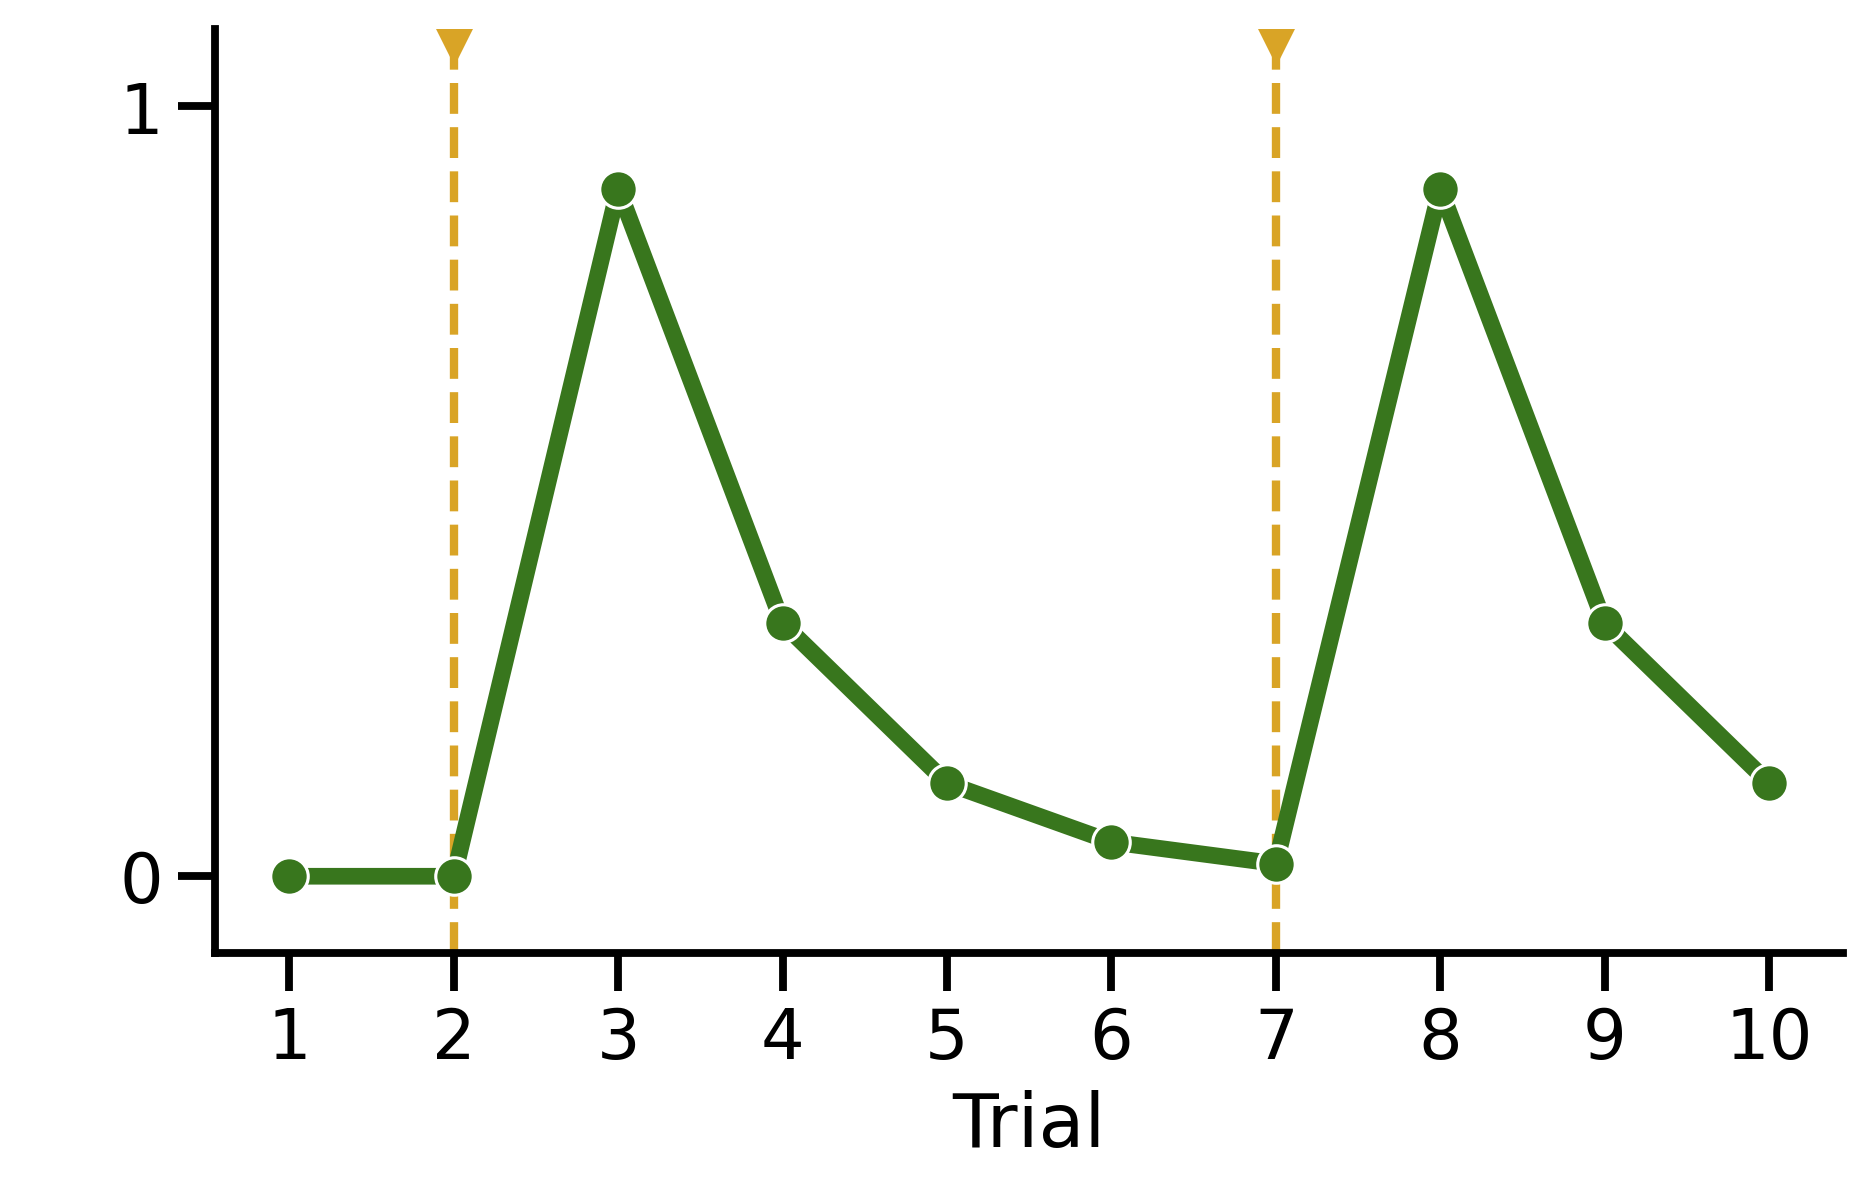

In [4]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

vddf = demo_data.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)



sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation_exp_tau1"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, marker="o")

ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(ylim)
ax.set_yticks(np.arange(0,2))
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_75809/2408501561.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


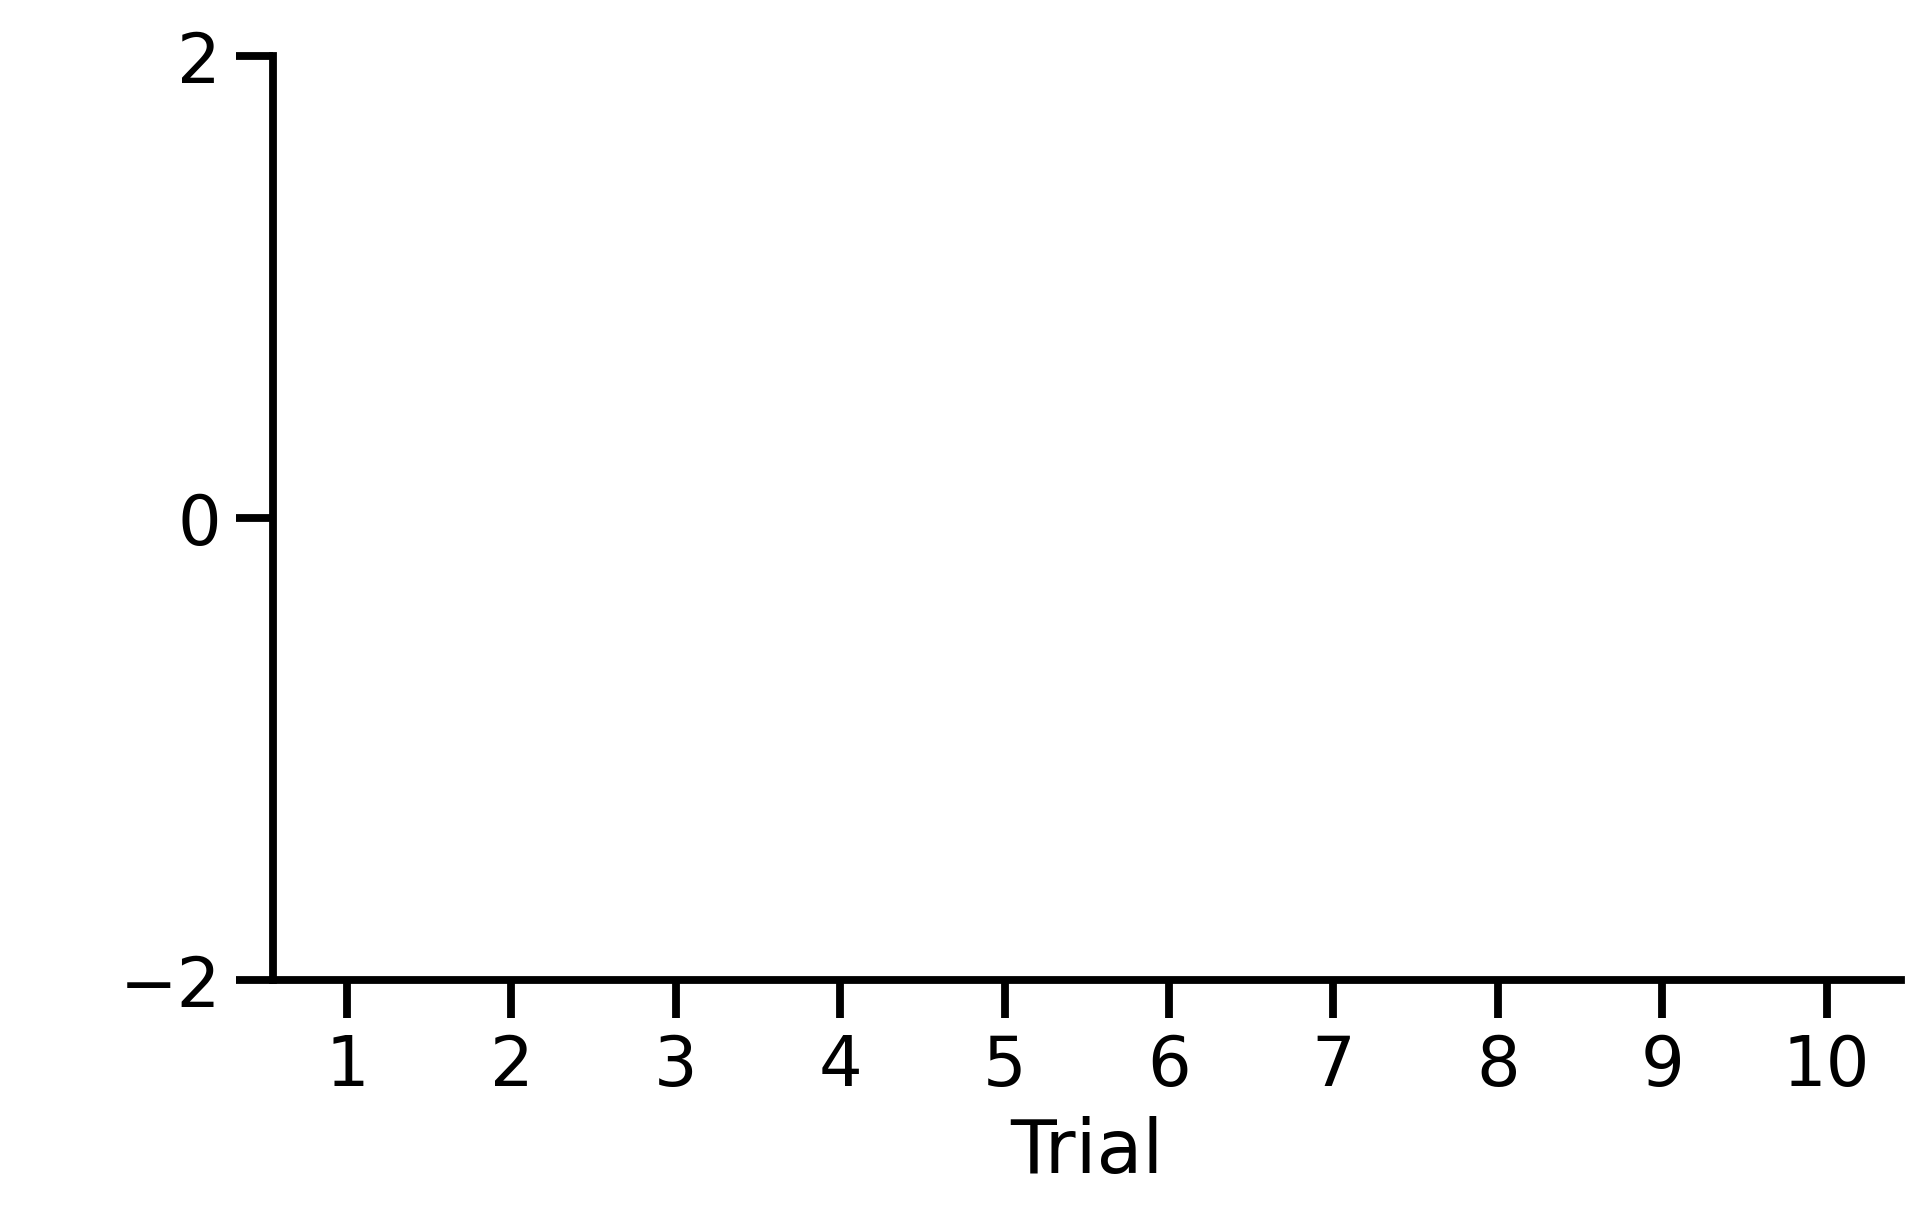

In [9]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

sns.lineplot(x=demo_data["trial"], y=demo_data["s_a"], drawstyle='steps-mid', label="", ax=ax, color="white", linewidth=4, marker="o")



ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(-2, 2)
ax.set_yticks([-2, 0, 2])
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_75809/1306818857.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


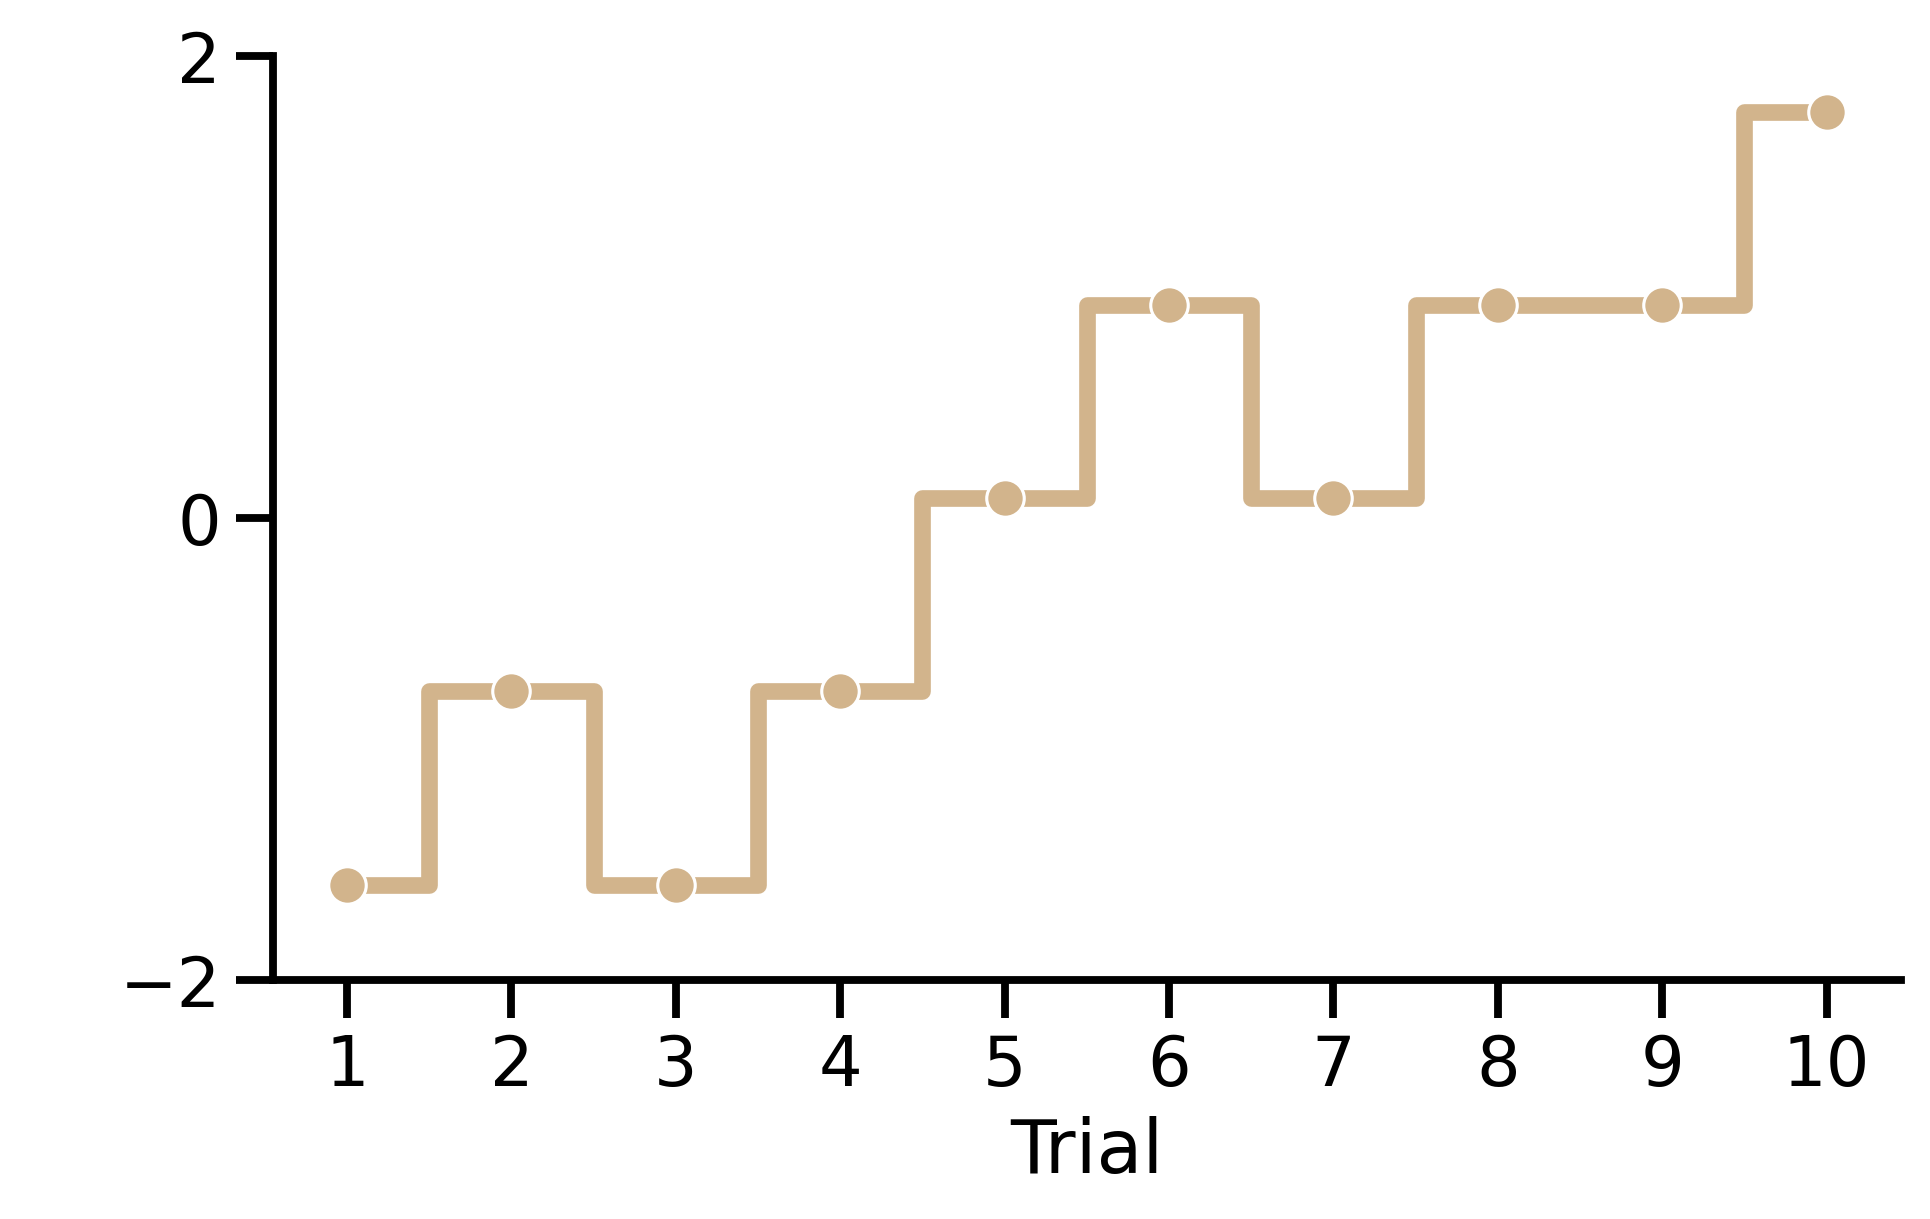

In [8]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

sns.lineplot(x=demo_data["trial"], y=demo_data["s_a"], drawstyle='steps-mid', label="", ax=ax, color="tan", linewidth=4, marker="o")



ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(-2, 2)
ax.set_yticks([-2, 0, 2])
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


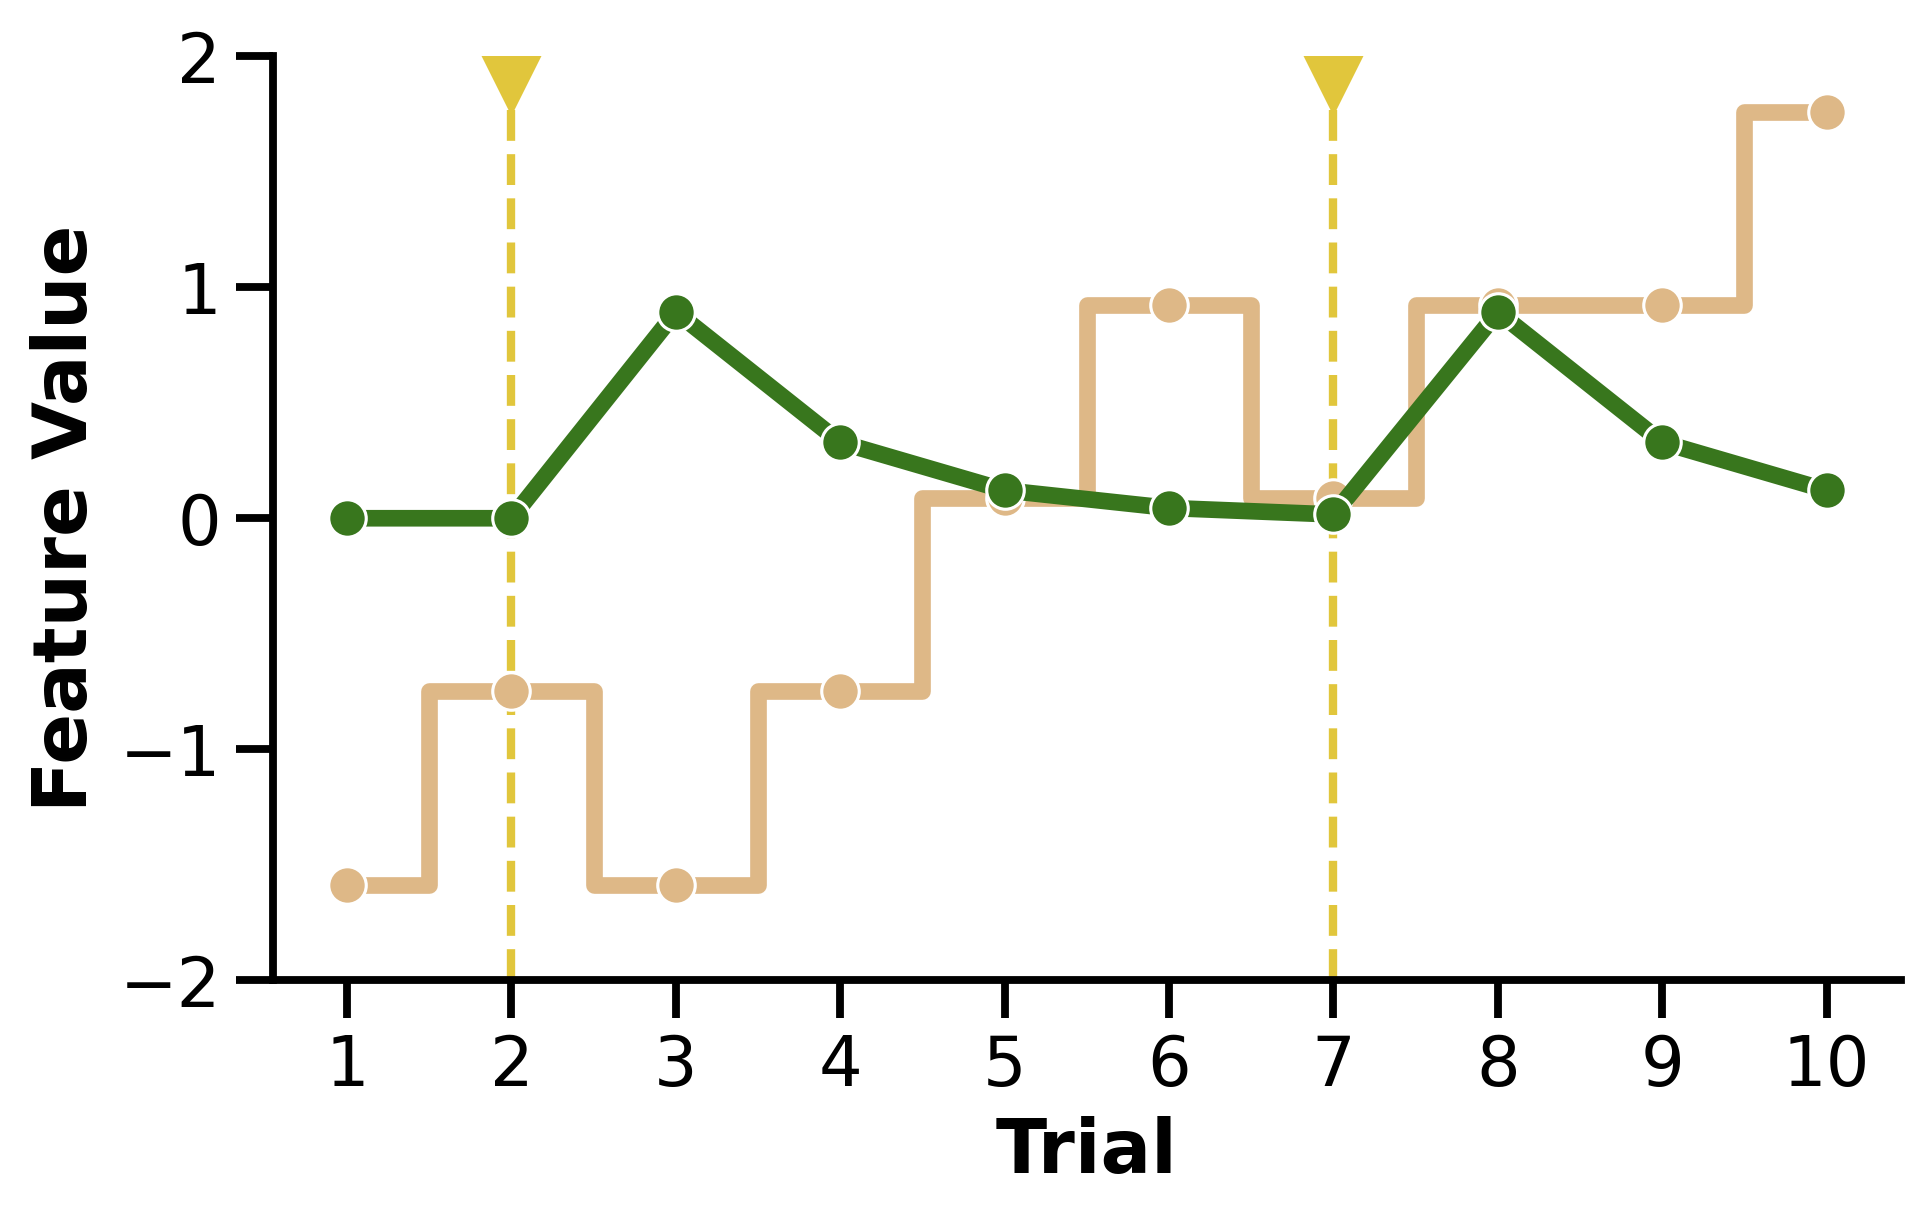

In [60]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

ax.scatter(vddf["trial"], (vddf["violation"] + 0.9), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["s_a"], drawstyle='steps-mid', label="", ax=ax, color="burlywood", linewidth=4, marker="o")

sns.lineplot(x=demo_data["trial"], y=demo_data["prev_violation_exp_tau1"], label="", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4, marker="o")


ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(-2, 2)
ax.set_yticks([-2, 0, 2])
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()


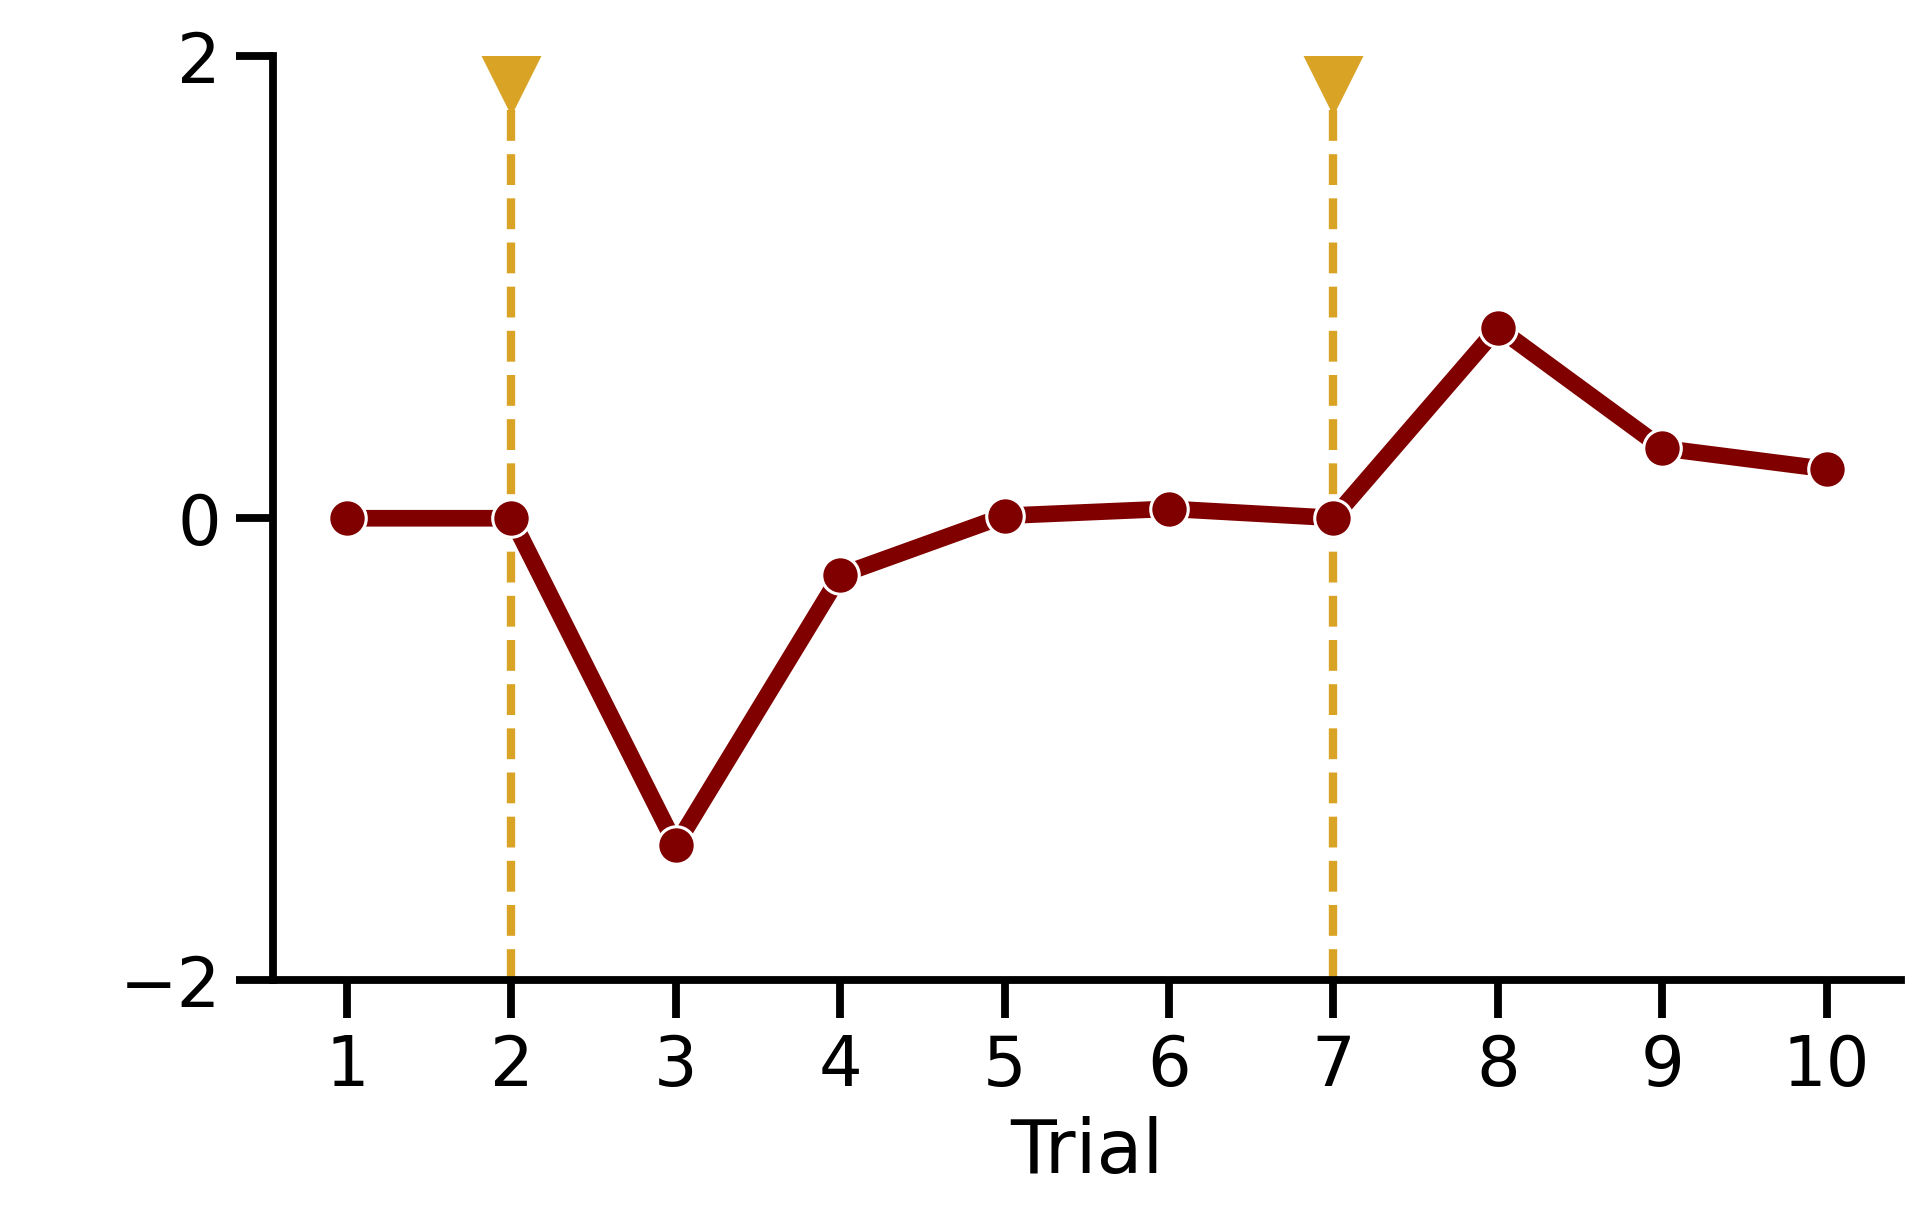

In [11]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=300) 

ax.scatter(vddf["trial"], (vddf["violation"] + 0.9), color=c.VIOLATION_COLOR_FPO, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR_FPO, linestyle='--', linewidth=2)

sns.lineplot(x=demo_data["trial"], y=demo_data["s_a_x_filt_prev_violation"], label="", ax=ax, color="maroon", linewidth=4, marker="o")



ax.legend().remove()
ax.set_xlabel("Trial")
ax.set_ylabel(" ")
ax.set_ylim(-2, 2)
ax.set_yticks([-2, 0, 2])
ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

## Weights


In [12]:
mvpv = ModelVisualizer(load_experiment(prev_viol_filtered_itrx_exp))
df = mvpv.unpack_features_and_weights()
df.feature.unique()


array(['bias', 's_a', 'sa_x_prev_viol', 's_b', 'sb_x_prev_viol',
       'filt_prev_violation', 'prev_stim_avg', 'prev_correct',
       'prev_choice'], dtype=object)

In [20]:
features = ["s_a","sa_x_prev_viol", "s_b", "sb_x_prev_viol"]
weight_class = ['L', 'R']
df = df.query("feature in @features and weight_class in @weight_class").copy()

YMIN=-2.1
YMAX=2.1

LABELS = [
    "Sound 1\nLoudness", 
    "Sound 2 &\nViolation Hist.",
    "Sound 2\nLoudness", 
    "Sound 2 &\nViolation Hist.",
]

COLORS = [
    "k",
    "maroon",
    "k",
    "maroon",
]


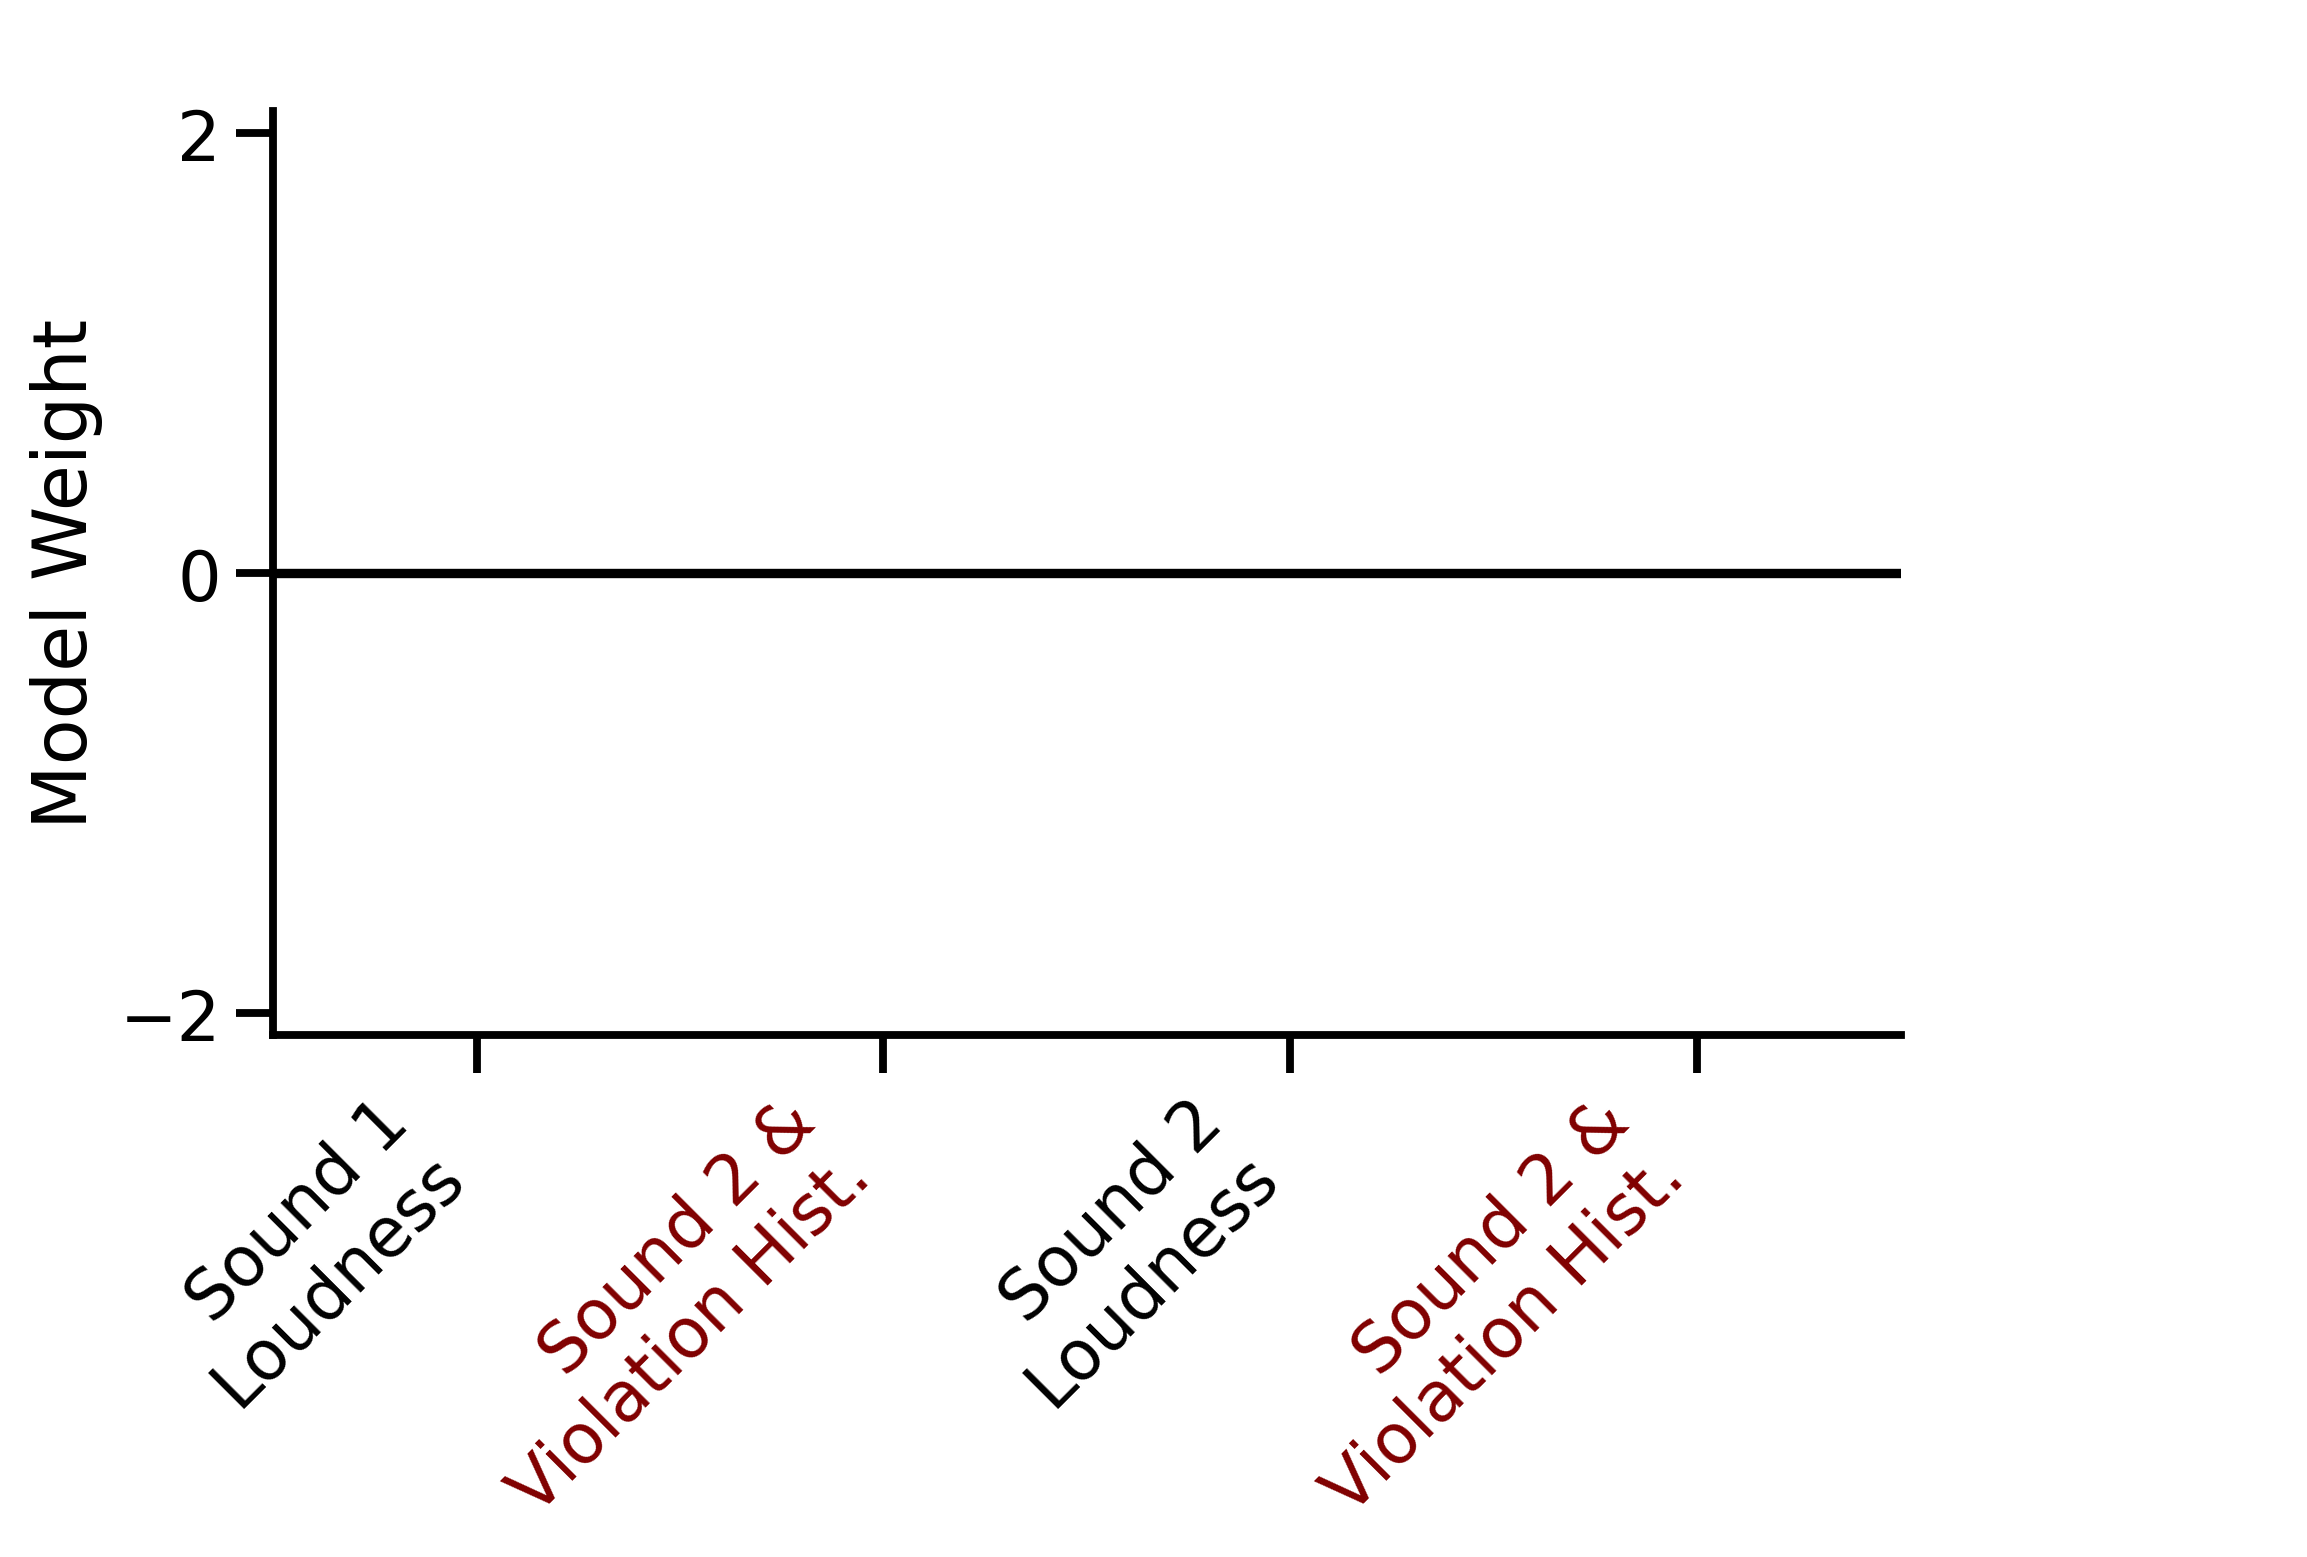

In [23]:

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)



palette = ["white", "white"]

mvpv.plot_weights_summary(df=df, ax=ax,style="point", plot_bias = False, title=" ", plot_individuals=False, seed=19, palette=palette,errorbar="se")

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)
for text in legend.get_texts():
    text.set_color("white")

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS, rotation=45, ha='right')
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("Model Weight", color="k")
ax.set_ylim(YMIN, YMAX)
ax.set_yticks([-2, 0, 2])





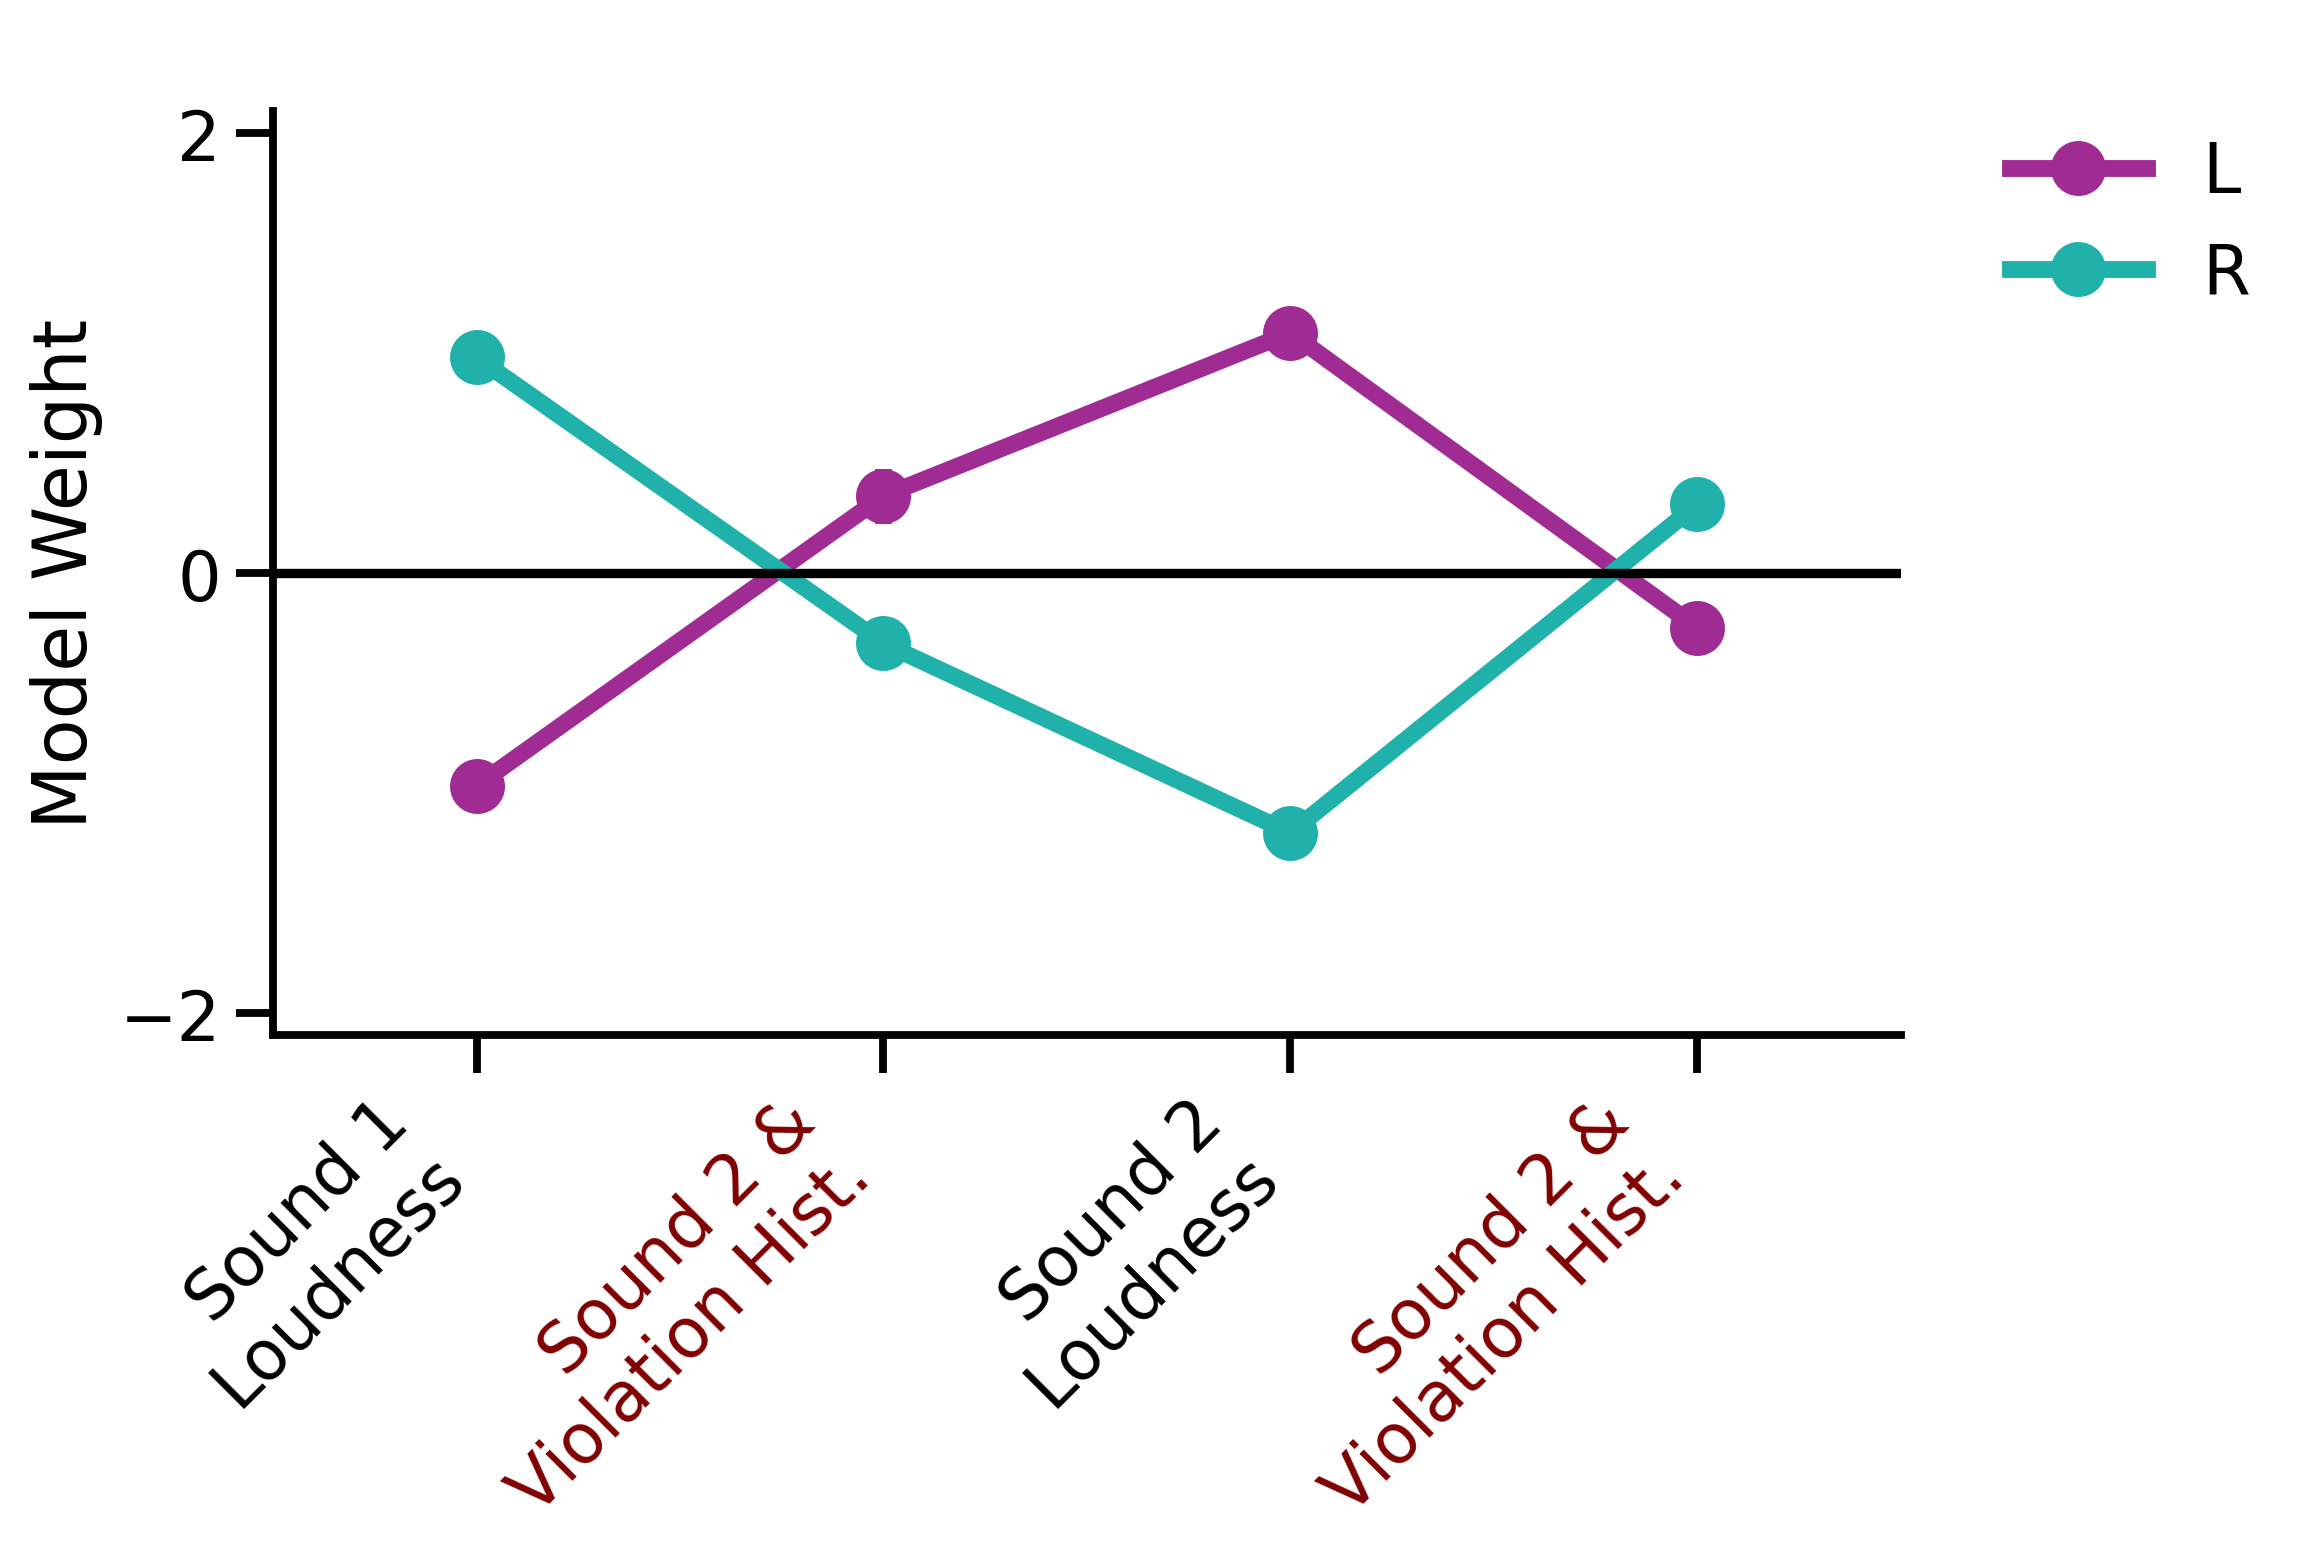

In [ ]:

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)



palette = [c.LEFT_COLOR_FPO, c.RIGHT_COLOR_FPO]

mvpv.plot_weights_summary(df=df, ax=ax,style="point", plot_bias = False, title=" ", plot_individuals=False, seed=19, palette=palette,errorbar="se")

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., frameon=False)

# set x labels
ax.set_xticks(range(len(LABELS)))
_ = ax.set_xticklabels(LABELS, rotation=45, ha='right')
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("Model Weight", color="k")
ax.set_ylim(YMIN, YMAX)
ax.set_yticks([-2, 0, 2])





## Compare- Multi


In [81]:
mvcm = ModelVisualizerCompare(load_experiment(compare_exp))

ORDER = [
    "base",
    "prev_viol_filtered",
    "prev_viol_filtered_itrx"
]
LABELS = [
    "Baseline",
    "Violation\nHistory",
    "Violation\nHistory x\nStimulus"
]
COLORS = [
    "k",
    "darkgreen",
    "olive"
]

bits_per_trial_df = mvcm.compute_bits_per_trial_df()
bits_per_trial_df.model_name.unique()

bits_per_trial_df = bits_per_trial_df.query("model_name == 'base' or model_name == 'prev_viol_filtered' or model_name == 'prev_viol_filtered_itrx'")

[Text(0.5, 0, ''), Text(0.5, 1.0, '')]

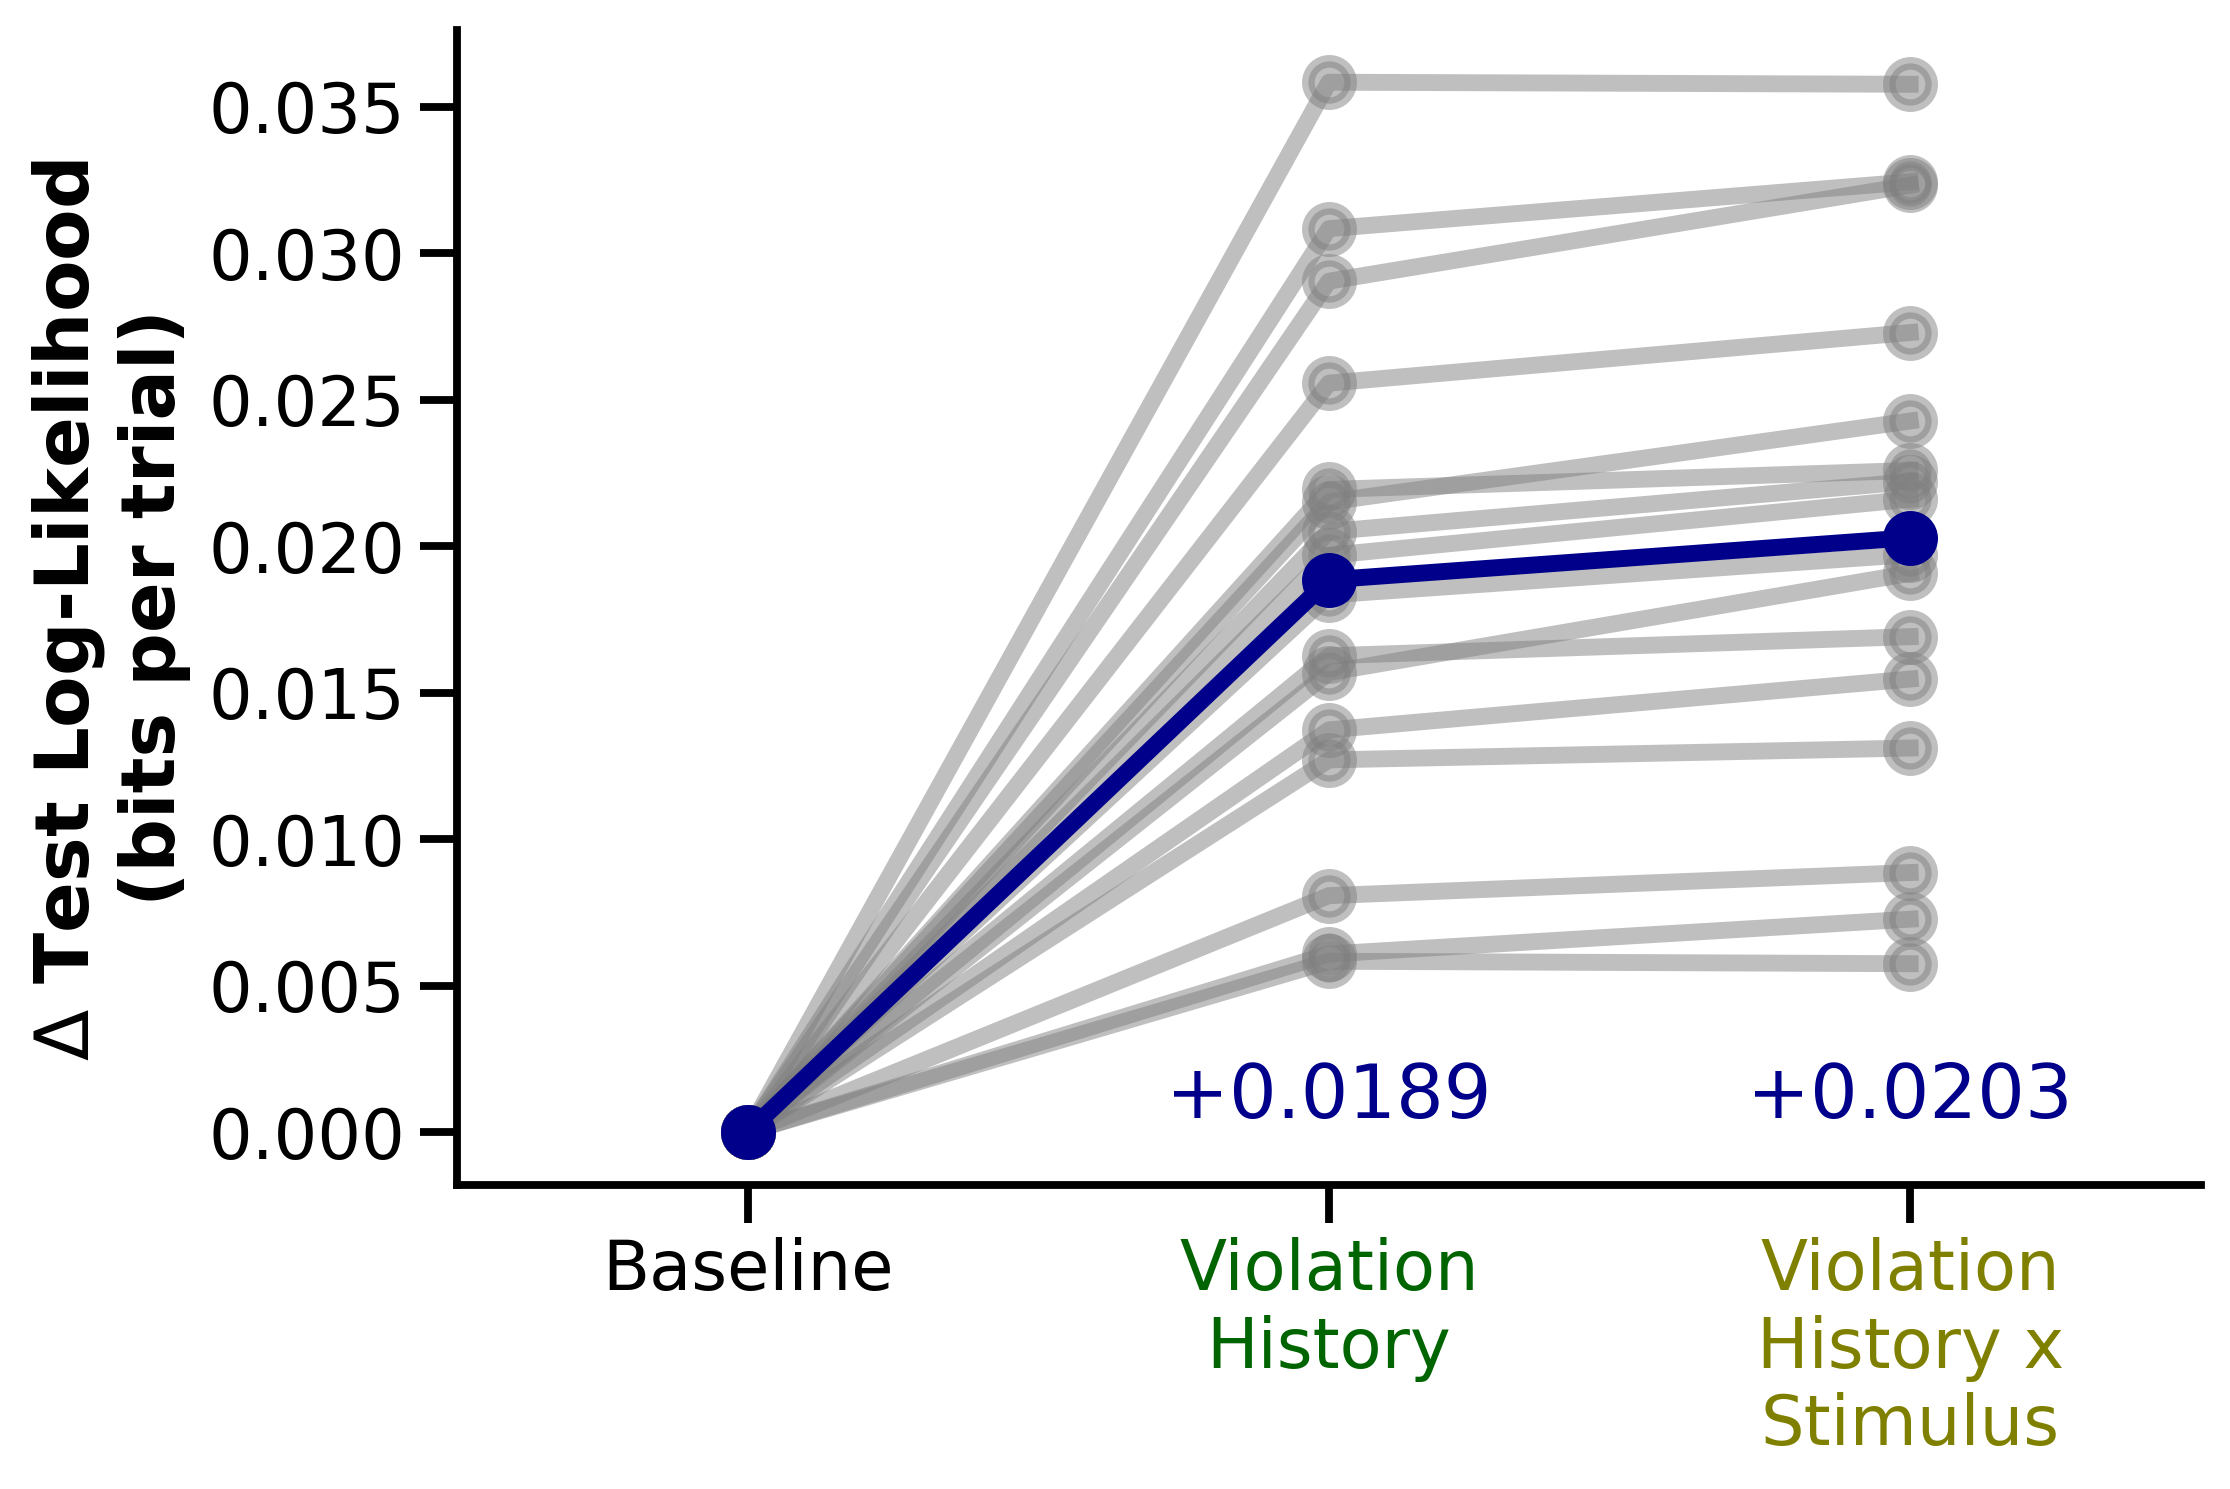

In [82]:
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=300)
sns.despine()
mvcm.plot_model_comparison(
    bits_per_trial_df,
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvcm.plot_model_comparison(
    bits_per_trial_df,
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ Test Log-Likelihood \n(bits per trial)",
    annotate=True,
    y_annotate=0.0005,
    color_annotate=c.MODEL_COMPARE_COLOR
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("$\Delta$ Test Log-Likelihood \n(bits per trial)", fontweight="bold")
ax.legend().remove()
ax.set(xlabel="", title="")

In [86]:
mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

{'geometric_mean_ratio': 2.994835777437509e+144,
 'log10_geometric_mean_ratio': 144.47637301273264}

In [87]:
mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")

{'geometric_mean_ratio': 3.191618687982257e+155,
 'log10_geometric_mean_ratio': 155.5040109993462}

In [88]:
mvcm.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 106570741274.93971,
 'log10_geometric_mean_ratio': 11.027637986613579}

## Compare- Binary


In [98]:
mvcb = ModelVisualizerCompare(load_experiment(binary_compare_exp))

ORDER = [
    "base",
    "prev_viol_filtered",
    "prev_viol_filtered_itrx"
]
LABELS = [
    "Baseline\nBinary",
    "Violation\nHistory",
    "Violation\nHistory x\nStimulus"
]
COLORS = [
    "k",
    "darkgreen",
    "olive"
]

bits_per_trial_df = mvcb.compute_bits_per_trial_df()
bits_per_trial_df.model_name.unique()

bits_per_trial_df = bits_per_trial_df.query("model_name == 'base' or model_name == 'prev_viol_filtered' or model_name == 'prev_viol_filtered_itrx'")

[Text(0.5, 0, ''), Text(0.5, 1.0, '')]

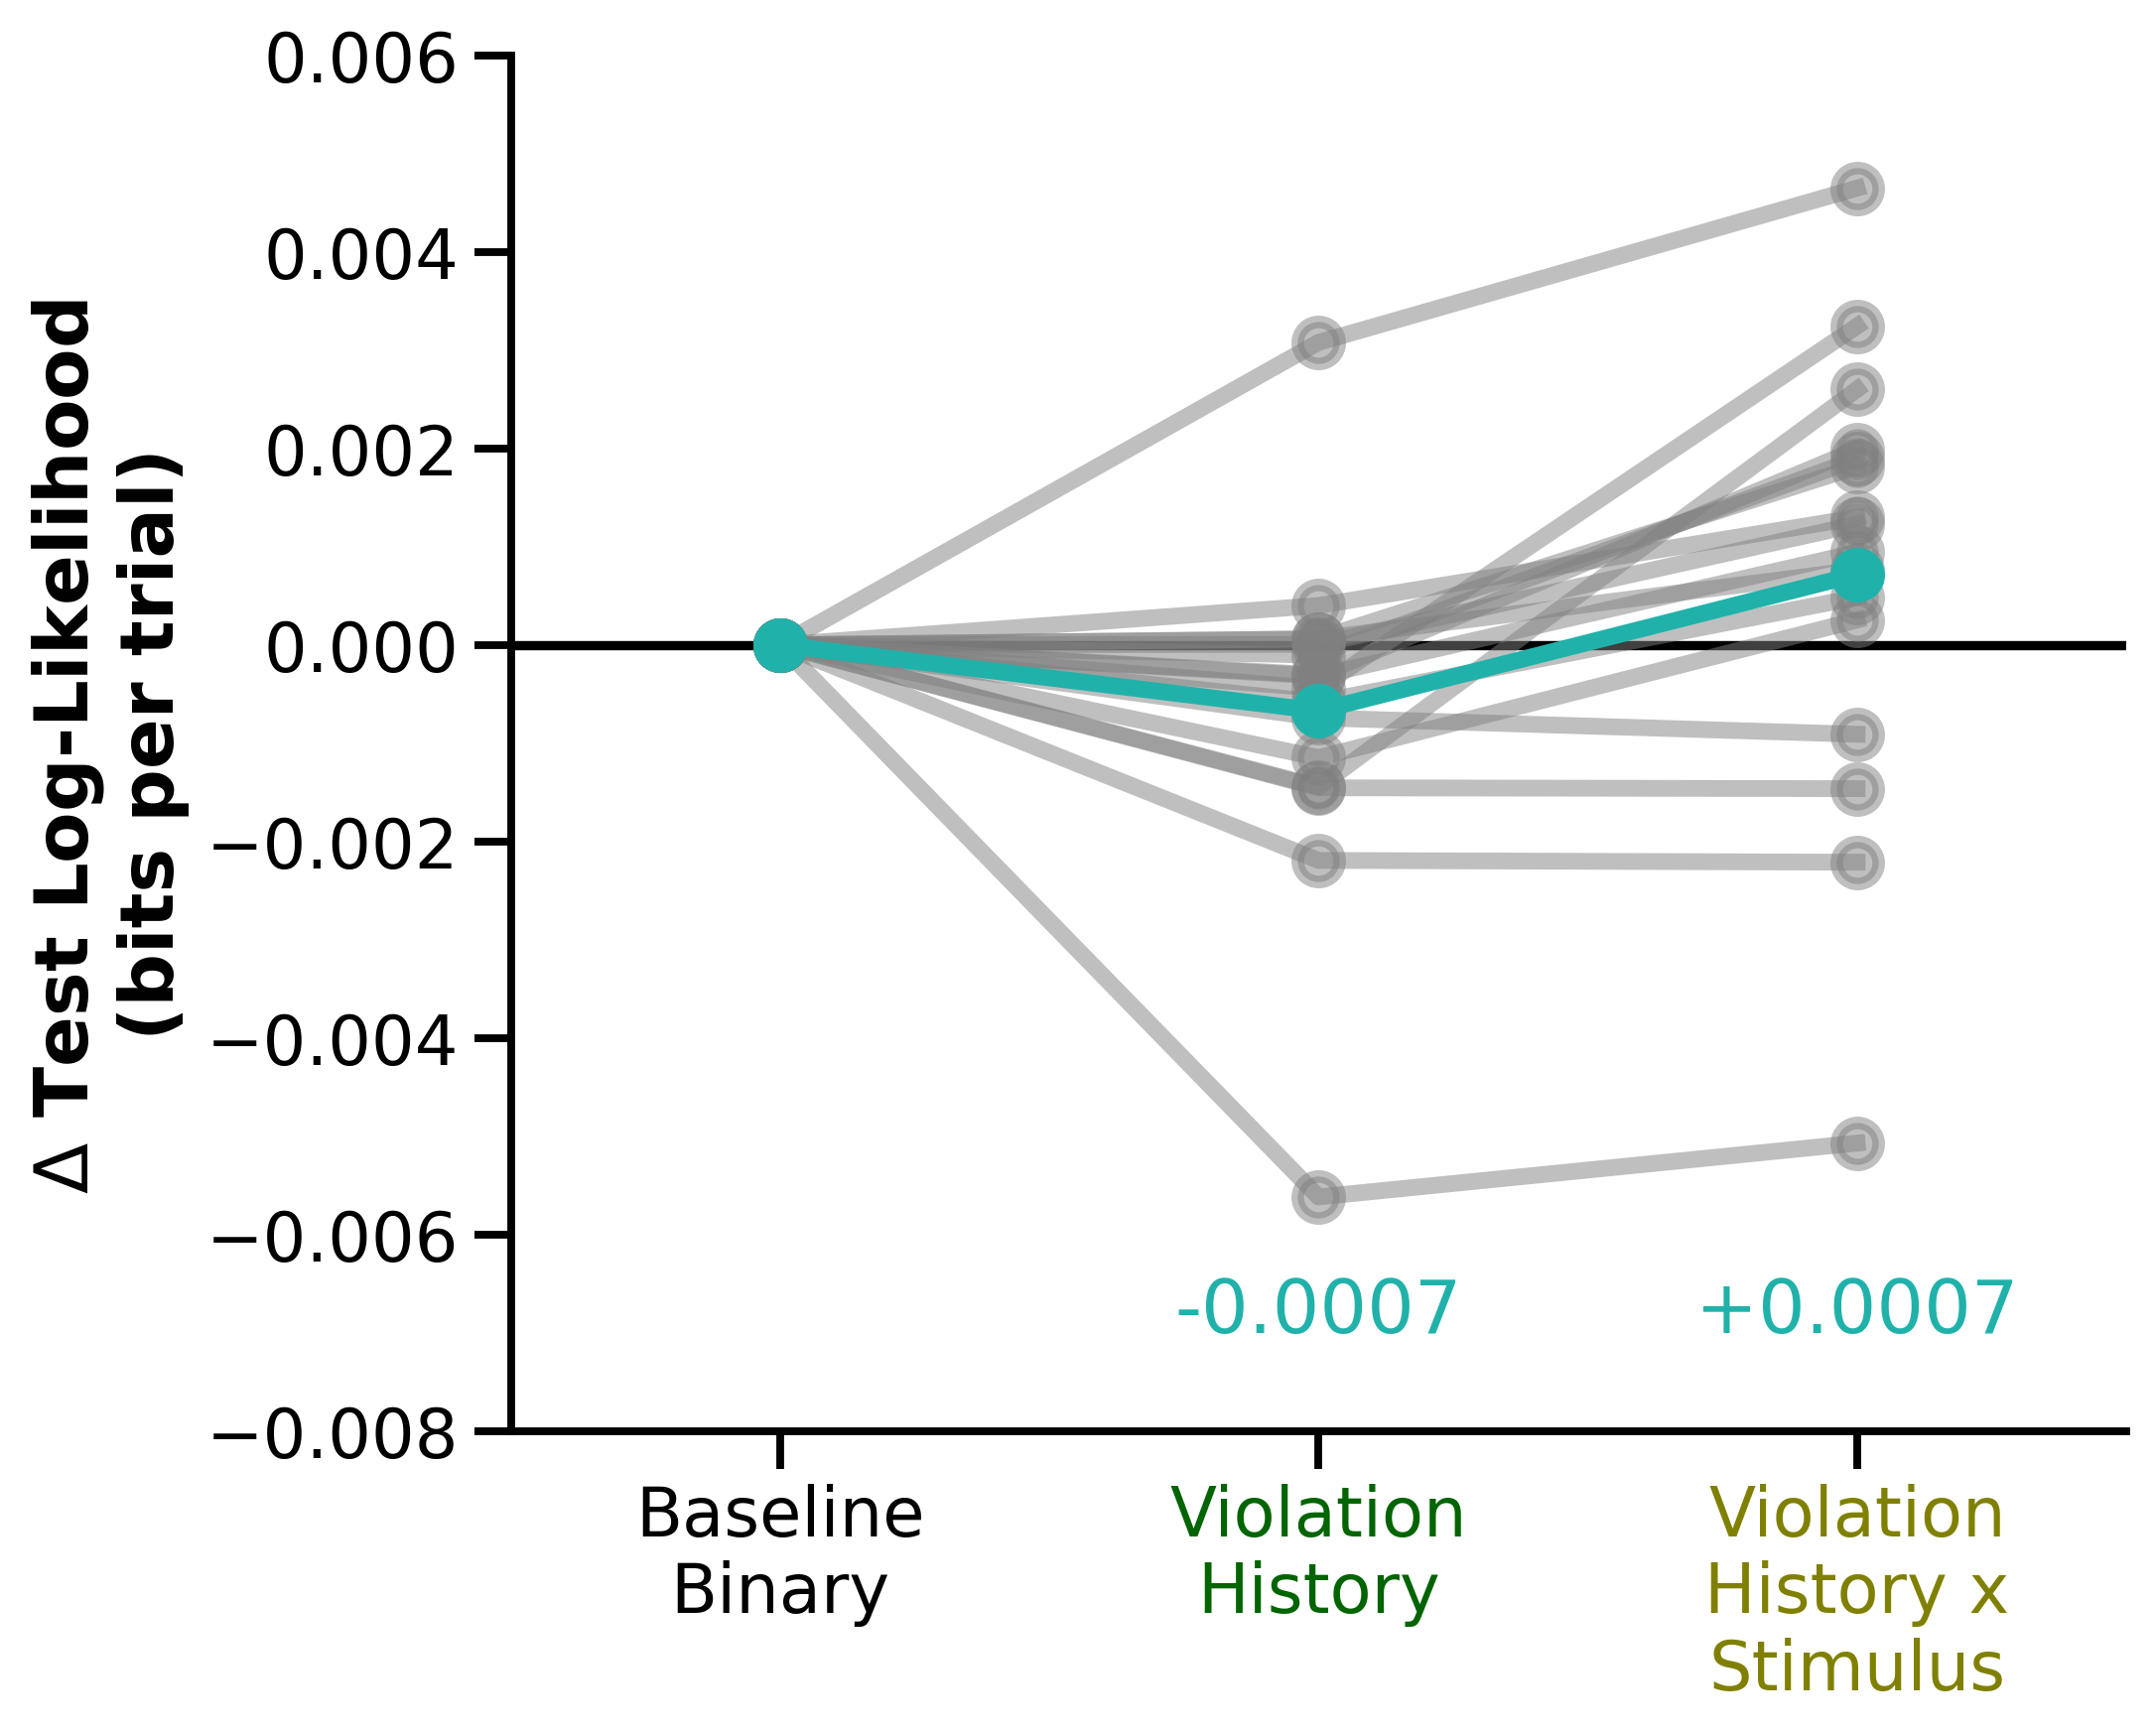

In [105]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
sns.despine()

ax.axhline(y=0, color="black", zorder=0)
mvcm.plot_model_comparison(
    bits_per_trial_df,
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvcm.plot_model_comparison(
    bits_per_trial_df,
    ax=ax,
    order=ORDER,
    color=c.BINARY_MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ Test Log-Likelihood \n(bits per trial)",
    annotate=True,
    y_annotate=-.007,
    color_annotate=c.BINARY_MODEL_COMPARE_COLOR
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)

ax.set_ylabel("$\Delta$ Test Log-Likelihood \n(bits per trial)", fontweight="bold")

ax.set_ylim(-.008, .006)
ax.legend().remove()
ax.set(xlabel="", title="")

In [101]:

mvcb.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 994026.1518503844,
 'log10_geometric_mean_ratio': 5.9973978104082875}